In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict, Any
from langchain_groq import ChatGroq
from dotenv import load_dotenv
import os

In [2]:
load_dotenv()

model = ChatGroq(model="llama-3.3-70b-versatile", 
                 api_key=os.getenv("API_KEY"),
                 temperature=0.1
                 )

In [3]:
class Blog(TypedDict):
    topic: str
    outline: str
    article: str

In [4]:
def Outline_node(state: Blog) -> Blog:
    topic = state['topic']
    prompt = f"Generate a outline on the {topic}"
    result = model.invoke(prompt)
    state['outline'] = result.content
    return state

In [5]:
def Article_node(state: Blog) -> Blog:
    outline = state['outline']
    prompt = f"Generate a detailed article based on the following outline: {outline}"
    result = model.invoke(prompt)
    state['article'] = result.content
    return state

In [10]:
graph = StateGraph(Blog)

graph.add_node("Outline_node",Outline_node)
graph.add_node("Article_node",Article_node)

graph.add_edge(START,"Outline_node")
graph.add_edge("Outline_node","Article_node")
graph.add_edge("Article_node",END)

workflow_agent=graph.compile()
initial_state={"topic":"Artificial Intelligence"}
result=workflow_agent.invoke(initial_state)
print(result['outline'])


Here is a comprehensive outline on Artificial Intelligence:

**I. Introduction to Artificial Intelligence**

* Definition of Artificial Intelligence (AI)
* Brief history of AI development
* Importance of AI in modern society

**II. Types of Artificial Intelligence**

* **Narrow or Weak AI**: Designed to perform a specific task
* **General or Strong AI**: Designed to perform any intellectual task
* **Superintelligence**: Significantly more intelligent than the best human minds
* **Artificial General Intelligence (AGI)**: A type of AI that can understand, learn, and apply knowledge across a wide range of tasks

**III. Machine Learning**

* **Definition**: A subset of AI that involves training algorithms on data to make predictions or decisions
* **Types of Machine Learning**:
	+ Supervised Learning
	+ Unsupervised Learning
	+ Reinforcement Learning
* **Applications of Machine Learning**: Image recognition, natural language processing, predictive analytics

**IV. Deep Learning**

* **Defi

In [12]:
print(result['article'])

**Introduction to Artificial Intelligence**

Artificial Intelligence (AI) refers to the development of computer systems that can perform tasks that typically require human intelligence, such as learning, problem-solving, and decision-making. The concept of AI has been around for decades, with the first AI program, called Logical Theorist, developed in 1956 by Allen Newell and Herbert Simon. Since then, AI has undergone significant advancements, with the development of machine learning, deep learning, and natural language processing. Today, AI plays a crucial role in modern society, with applications in various industries, including healthcare, finance, transportation, and education.

The history of AI development can be divided into several phases. The first phase, which lasted from the 1950s to the 1970s, focused on the development of rule-based systems that could reason and solve problems. The second phase, which lasted from the 1980s to the 1990s, focused on the development of exper

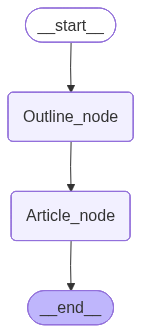

In [7]:
from IPython.display import display, Markdown,Image
Image(workflow_agent.get_graph().draw_mermaid_png())